# To check RF position to QDSPY coordinate transrom

### imports

In [306]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [307]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

from IPython.display import display



In [309]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"model_in_the_loop/config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))



home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/model_in_the_loop/config
Configuration loaded successfully:
paths:
  repo_directory: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/
  home_directory: /gpfs01/euler/User/ssuhai
  dj_config_directory: datajoint
  rgc_output_directory: datajoint/rgc_classifier
  recording_files_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/data/new_data_dump
  stimulus_output_dir: /gpfs01/euler/data/Data/Suhai/stimuli_closed_loop
  dummy_ini_dir: model_in_the_loop/data/dummy_ini/
ini_file_keys:
  string_userName: clexperimenter
  string_projName: projectname
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: ${paths.repo_directory}model_in_the_loop/data/data_dj_format
  table_parameters:
    PreprocessParams:
    - preprocess_id: 1
      fs_resample: 60
 

### Create processing components (connect them to DB)

In [310]:
from model_in_the_loop.core import DJTableHolder

In [312]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore

                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )



In [320]:
from model_in_the_loop.core import STAWrapper,QualityAndTypeWrapper

In [321]:
sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder
)

In [313]:


dj_table_holder.setup()




schema_name: ageuler_ssuhai_closed_loop


[2025-09-30 18:10:56,358][WARNING]: MySQL server has gone away. Reconnecting to the server.


Done reconnecting. Skipping adding new entries from config.


--- Logging error ---
Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/datajoint/connection.py", line 343, in query
    self._execute_query(cursor, query, args, suppress_warnings)
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/datajoint/connection.py", line 299, in _execute_query
    raise translate_query_error(err, query)
datajoint.errors.LostConnectionError: ('Connection timed out', "MySQL server has gone away (SSLEOFError(8, 'EOF occurred in violation of protocol (_ssl.c:2417)'))")

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/logging/__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
ValueError: I/O operation on closed file.
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/.pyenv/versions

### get data

In [ ]:
save_dir = '/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/validate_stimulus_presentation'

In [322]:
sta_wrapper.compute_analysis()

Processes: 100%|██████████| 107/107 [00:01<00:00, 64.85it/s]


In [ ]:
import pandas as pd
import numpy as np

In [327]:

FitGauss2DRF = pd.DataFrame(dj_table_holder("FitGauss2DRF")().fetch("roi_id","srf_params",as_dict = True))
FitGauss2DRF.head()

SplitRF = pd.DataFrame(dj_table_holder("SplitRF")().fetch("roi_id","srf",as_dict = True))
SplitRF.head()

,roi_id,srf
0,1,"[[0.0003529344, 0.00683742, 0.012378743, 0.014..."
1,2,"[[0.03731215, 0.034479395, 0.01676022, 0.00819..."
2,3,"[[0.02070851, 0.027906075, 0.03203959, 0.02692..."
3,4,"[[-0.0047674784, -0.015362144, -0.010597402, 0..."
4,5,"[[-0.00640598, -0.0050259423, 0.0048288973, 0...."


In [328]:
import pickle

# save fit 
with open(os.path.join(save_dir,'fit_gauss_2d_rf_20200226.pkl'),'wb') as f:
    pickle.dump(FitGauss2DRF,f)


with open(os.path.join(save_dir,'split_rf_20200226.pkl'),'wb') as f:
    pickle.dump(SplitRF,f)


In [331]:
import thesis.code.validate_stimulus_presentation.rf_pres_utils as rf_utils


# Look at sRF and mean

In [333]:
# show the first frame of Dnoise
import h5py
import matplotlib.pyplot as plt 
with h5py.File("/gpfs01/euler/data/Resources/Stimulus/noise.h5", "r") as f:
    noise_stimulus = f['stimulusarray'][:].T.astype(int)

srf table x mean 2.229182394484366 
srf table y mean 0.0012598706996744663
srf table x mean 6.542484747594704 
srf table y mean 12.333126650488744
srf table x mean 7.715354056037649 
srf table y mean 11.986590238431516
srf table x mean 6.137785580953378 
srf table y mean 11.66962687558501
srf table x mean 7.65265068286817 
srf table y mean 11.248181282496972
srf table x mean 8.653202505379326 
srf table y mean 10.787886075148602
srf table x mean 8.505208583707164 
srf table y mean 10.525340405280964
srf table x mean 5.904205162993284 
srf table y mean 10.330300203883706
srf table x mean 7.439688241466339 
srf table y mean 9.168630407895455
srf table x mean 8.206726528890343 
srf table y mean 19.161477606850617
srf table x mean 6.495985951710527 
srf table y mean 10.311610127153514
srf table x mean 9.243086797141016 
srf table y mean 8.945127851407964
srf table x mean 5.262683764794529 
srf table y mean 10.895245215813572
srf table x mean 8.466570087343614 
srf table y mean 9.4258355871

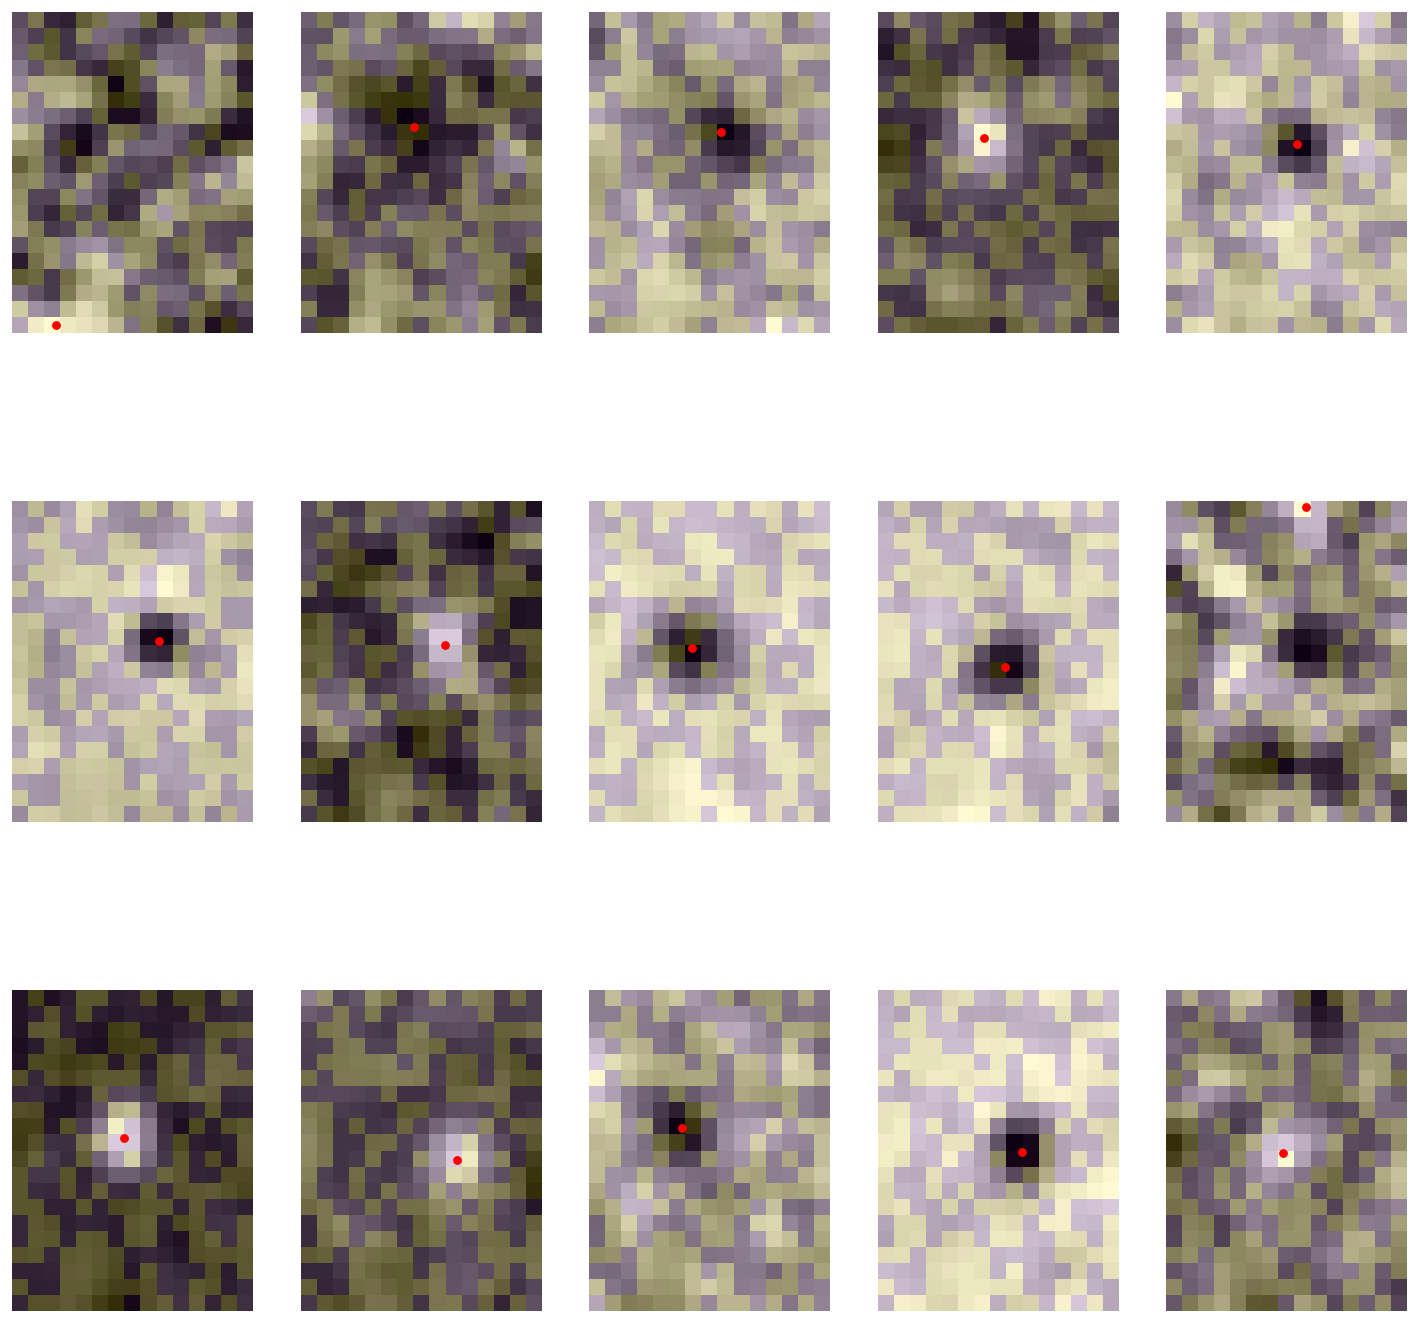

In [355]:
rois = [3, 4, 11, 21, 33, 35, 42, 47, 62, 66, 71, 78, 80, 86, 87]
fig,ax = plt.subplots(3, 5, figsize=(15, 15))
ax = ax.flatten()
# roi 27 has nice RF look at peak position
for i,r in enumerate(rois):

    rf_utils.plot_srf_pos(r,
                        FitGauss2DRF=FitGauss2DRF,
                        SplitRF=SplitRF,
                        rf_kwargs={"alpha":0.8},
                        noise_stimulus=noise_stimulus,
                        ax = ax[i])

srf table x mean 8.505208583707164 
srf table y mean 10.525340405280964


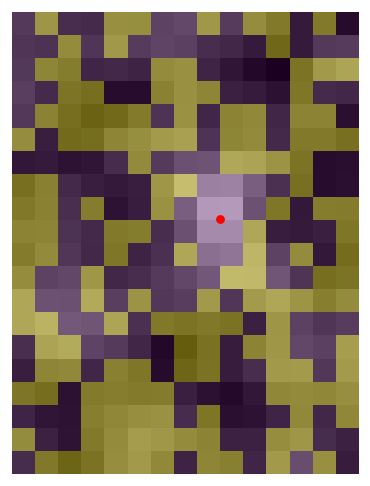

In [ ]:
rf_utils.plot_srf_pos(42,
                        FitGauss2DRF=FitGauss2DRF,
                        SplitRF=SplitRF,
                        rf_kwargs={"alpha":0.6},
                        noise_stimulus=noise_stimulus)

srf table x mean 8.653202505379326 
srf table y mean 10.787886075148602


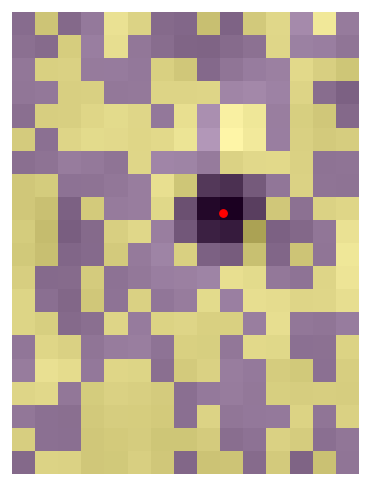

In [359]:
rf_utils.plot_srf_pos(rois[5],
                        FitGauss2DRF=FitGauss2DRF,
                        SplitRF=SplitRF,
                        rf_kwargs={"alpha":0.6},
                        noise_stimulus=noise_stimulus)

srf table x mean 6.137785580953378 
srf table y mean 11.66962687558501


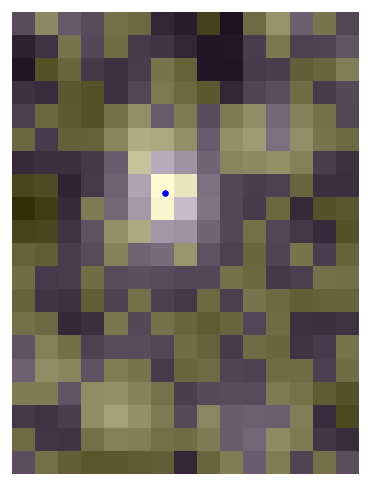

In [376]:
rf_utils.plot_srf_pos(rois[3],
                        FitGauss2DRF=FitGauss2DRF,
                        SplitRF=SplitRF,
                        rf_kwargs={"alpha":0.8},
                        noise_stimulus=noise_stimulus)

srf table x mean 7.65265068286817 
srf table y mean 11.248181282496972


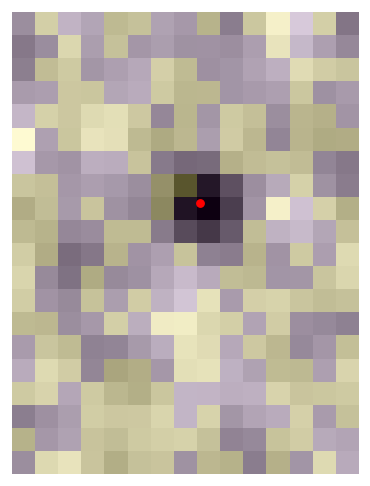

In [363]:
rf_utils.plot_srf_pos(33,
                        FitGauss2DRF=FitGauss2DRF,
                        SplitRF=SplitRF,
                        rf_kwargs={"alpha":0.8},
                        noise_stimulus=noise_stimulus)

# coordinate transforms

In [365]:
from model_in_the_loop.utils.transform_to_avi_stimulus import extract_rf_means_from_selected_rois

In [366]:
all_x_um, all_y_um,roi_order = extract_rf_means_from_selected_rois(roi_ids=rois,
                                    stimulus_table=dj_table_holder("Stimulus")(),
                                    gauss_rf_fit_table=dj_table_holder("FitGauss2DRF")(),)

[2025-09-30 19:20:58,838][WARNING]: MySQL server has gone away. Reconnecting to the server.


Found 15 rois in the FitGauss2D table.


--- Logging error ---
Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/datajoint/connection.py", line 343, in query
    self._execute_query(cursor, query, args, suppress_warnings)
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/datajoint/connection.py", line 299, in _execute_query
    raise translate_query_error(err, query)
datajoint.errors.LostConnectionError: ('Server connection lost', 'Lost connection to MySQL server during query')

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/logging/__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
ValueError: I/O operation on closed file.
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipyk

In [369]:
transformed_roi_xy = {roi: (x,y) for roi,x,y in zip(roi_order,all_x_um,all_y_um)}

# save transformed coordinates
with open(os.path.join(save_dir,'transformed_roi_xy_20200226.pkl'),'wb') as f:
    pickle.dump(transformed_roi_xy,f)

In [373]:
transformed_roi_xy[rois[3]]

(86, -34)

In [374]:
rois[3]

21

In [54]:
(dj_table_holder("FitGauss2DRF")() & dict(roi_id=33)).fetch1("srf_params")

{'amplitude': 0.26013551882805547,
 'x_mean': 6.9736971709146784,
 'y_mean': 10.274709248252908,
 'x_stddev': 1.1195782664669898,
 'y_stddev': 1.5785941594830704,
 'theta': -0.44956010572317856}

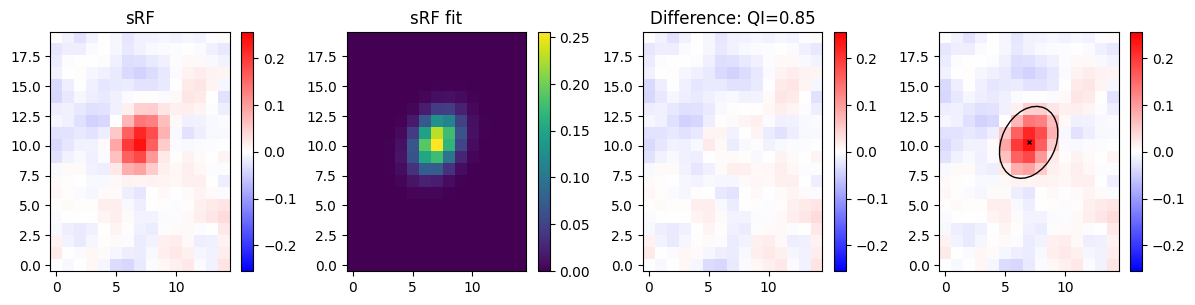

In [55]:
(dj_table_holder("FitGauss2DRF")() & dict(roi_id=33)).plot1()